In [25]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 67 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [26]:

df=pd.read_csv('/content/drive/MyDrive/실습파일/연습용.csv')
df.info()

df.isnull()
df=pd.DataFrame(df)
df=df.drop(columns=['UDI','Product ID'])
df=pd.get_dummies(df,columns=['Type'],dtype=int)
print(df)


#그래프 정보 및 결측치 확인



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB
      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                   298.1                    308.6                    1551   
1                   298.2                    308.7                    1408   
2

In [27]:
print(df)
df['Machine failure'].value_counts()


      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                   298.1                    308.6                    1551   
1                   298.2                    308.7                    1408   
2                   298.1                    308.5                    1498   
3                   298.2                    308.6                    1433   
4                   298.2                    308.7                    1408   
...                   ...                      ...                     ...   
9995                298.8                    308.4                    1604   
9996                298.9                    308.4                    1632   
9997                299.0                    308.6                    1645   
9998                299.0                    308.7                    1408   
9999                299.0                    308.7                    1500   

      Torque [Nm]  Tool wear [min]  Machine failure  Type_H  Ty

,count
Machine failure,
0,9661
1,339


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
#요인들과 결함률 상관관계 확인


corr=df.corr()
var=corr['Machine failure'].drop(['Machine failure'])
var


,Machine failure
Air temperature [K],0.082556
Process temperature [K],0.035946
Rotational speed [rpm],-0.044188
Torque [Nm],0.191321
Tool wear [min],0.105448
Type_H,-0.023916
Type_L,0.035643
Type_M,-0.022432


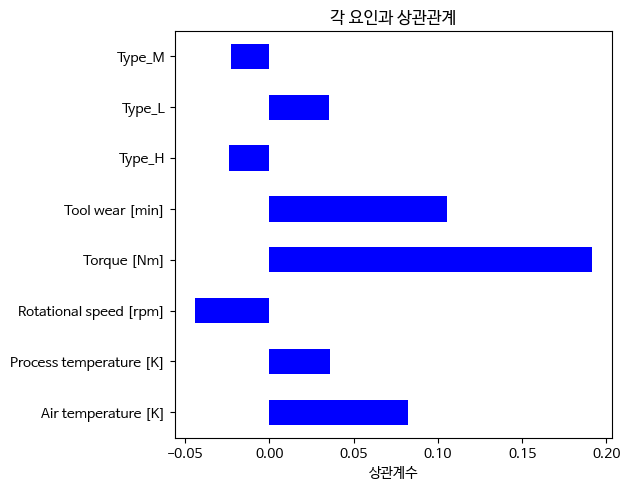

In [30]:
#어떤 요인이 상관관계가 큰지 확인
bar1=var.plot(kind='barh',color='blue')
plt.xlabel('상관계수')
plt.tight_layout()
plt.title('각 요인과 상관관계')

plt.savefig('/content/drive/MyDrive/실습파일/corr',bbox_inches='tight')

plt.show()


In [31]:
#각 요인들 구간별 기계 결함 수 관계

df.describe()



,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_H,Type_L,Type_M
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.100300,0.600000,0.299700
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.300415,0.489922,0.458149
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,1.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,1.000000,1.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000


In [81]:
#타입별 셈플 수
type_count = df[['Type_H', 'Type_L', 'Type_M']].sum()
type_count

,0
Type_H,1003
Type_L,6000
Type_M,2997


In [84]:
import matplotlib.pyplot as plt
types=['Type_H', 'Type_L', 'Type_M']
for n in types:
  typefailure[n]=df.loc[df[n]==1,'Machine failure'].sum()
for n in types:
  typefailure[n]=typefailure[n]/type_count[n]*100
print(typefailure)



Type_H    2.093719
Type_L    3.916667
Type_M    2.769436
dtype: float64


In [32]:
#공기 온도
#구간별 결함률에 영향이 있는지 확인
#구간 나누기위한 변수 범위 확인
atpanel=pd.cut(df['Air temperature [K]'],bins=5)
atfailure=df.groupby(atpanel)['Machine failure'].sum()
print(atfailure)

Air temperature [K]
(295.291, 297.14]     16
(297.14, 298.98]      61
(298.98, 300.82]      74
(300.82, 302.66]     118
(302.66, 304.5]       70
Name: Machine failure, dtype: int64


/tmp/ipykernel_757/4139661141.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  atfailure=df.groupby(atpanel)['Machine failure'].sum()


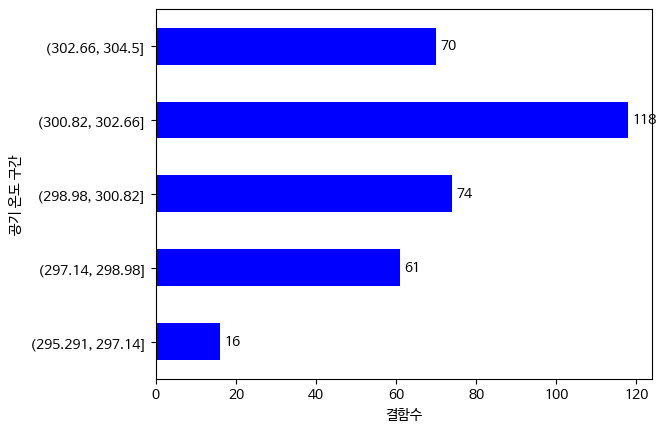

In [33]:
g6=atfailure.plot(kind='barh',color='blue')
plt.xlabel('결함수')
plt.ylabel('공기 온도 구간')
for i, v in enumerate(atfailure.values):
    g6.text(v + 1, i,str(v), color='black', va='center', ha='left')
plt.savefig('/content/drive/MyDrive/실습파일/air',bbox_inches='tight')
plt.show()

In [34]:
#공구 사용시간
twpanel=pd.cut(df['Tool wear [min]'],bins=5)
twfailure=df.groupby(twpanel)['Machine failure'].sum()
print(twfailure)



Tool wear [min]
(-0.253, 50.6]     52
(50.6, 101.2]      56
(101.2, 151.8]     48
(151.8, 202.4]     70
(202.4, 253.0]    113
Name: Machine failure, dtype: int64


/tmp/ipykernel_757/1602059485.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  twfailure=df.groupby(twpanel)['Machine failure'].sum()


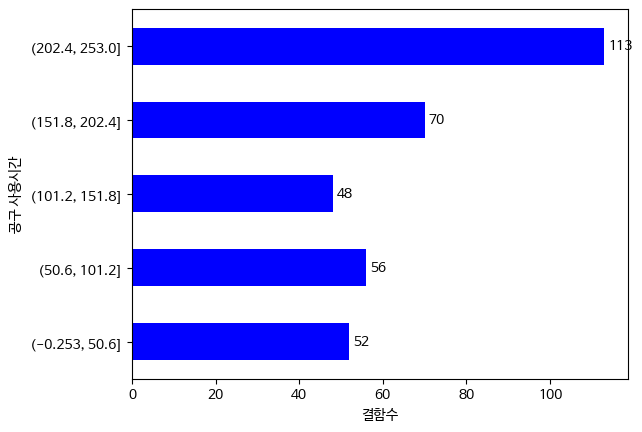

In [35]:
g5=twfailure.plot(kind='barh',color='blue')
plt.xlabel('결함수')
plt.ylabel('공구 사용시간')
for i, v in enumerate(twfailure.values):
    g5.text(v + 1, i,str(v), color='black', va='center', ha='left')
plt.savefig('/content/drive/MyDrive/실습파일/tool',bbox_inches='tight')
plt.show()

In [36]:
#회전력
tpanel=pd.cut(df['Torque [Nm]'],bins=5)
tfailure=df.groupby(tpanel)['Machine failure'].sum()
print(tfailure)

Torque [Nm]
(3.727, 18.36]     32
(18.36, 32.92]     15
(32.92, 47.48]     51
(47.48, 62.04]    166
(62.04, 76.6]      75
Name: Machine failure, dtype: int64


/tmp/ipykernel_757/3618511011.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tfailure=df.groupby(tpanel)['Machine failure'].sum()


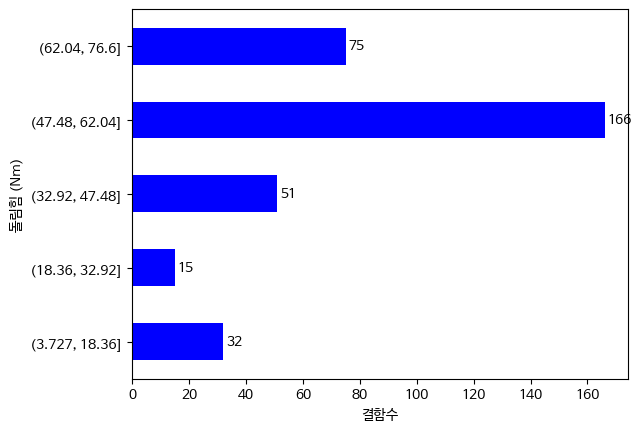

In [37]:
g4=tfailure.plot(kind='barh',color='blue')
plt.xlabel('결함수')
plt.ylabel('돌림힘 (Nm)')
for i, v in enumerate(tfailure.values):
    g4.text(v + 1, i,str(v), color='black', va='center', ha='left')

plt.savefig('/content/drive/MyDrive/실습파일/torque',bbox_inches='tight')
plt.show()

In [38]:
rspanel=pd.cut(df['Rotational speed [rpm]'],bins=5)
rsfailure=df.groupby(rspanel)['Machine failure'].sum()
print(rsfailure)

Rotational speed [rpm]
(1166.282, 1511.6]    281
(1511.6, 1855.2]       21
(1855.2, 2198.8]        6
(2198.8, 2542.4]        5
(2542.4, 2886.0]       26
Name: Machine failure, dtype: int64


/tmp/ipykernel_757/2909809179.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rsfailure=df.groupby(rspanel)['Machine failure'].sum()


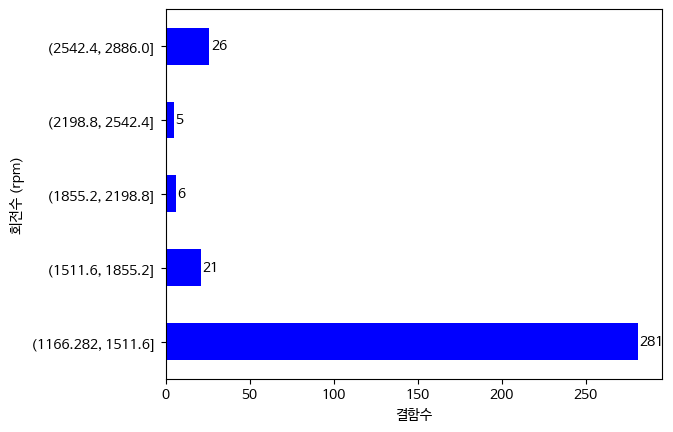

In [39]:
g3=rsfailure.plot(kind='barh',color='blue')
plt.xlabel('결함수')
plt.ylabel('회전수 (rpm)')
for i, v in enumerate(rsfailure.values):
    g3.text(v + 1, i,str(v), color='black', va='center', ha='left')
plt.savefig('/content/drive/MyDrive/실습파일/rot',bbox_inches='tight')
plt.show()

In [40]:
ptpanel=pd.cut(df['Process temperature [K]'],bins=5)
ptfailure=df.groupby(ptpanel)['Machine failure'].sum()
print(ptfailure)

Process temperature [K]
(305.692, 307.32]      5
(307.32, 308.94]      61
(308.94, 310.56]     115
(310.56, 312.18]     136
(312.18, 313.8]       22
Name: Machine failure, dtype: int64


/tmp/ipykernel_757/3715905733.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ptfailure=df.groupby(ptpanel)['Machine failure'].sum()


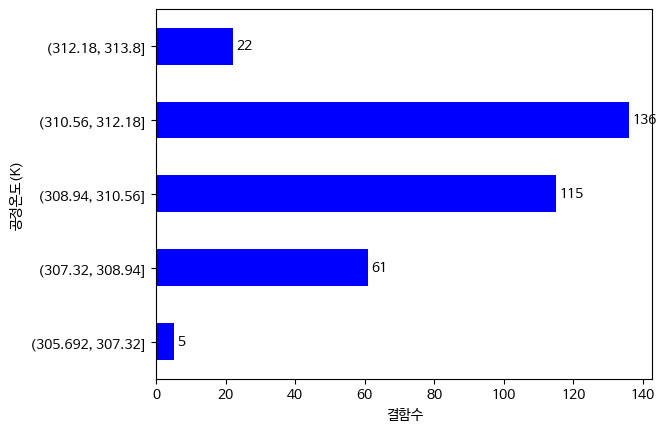

In [41]:
g2=ptfailure.plot(kind='barh',color='blue')
plt.xlabel('결함수')
plt.ylabel('공정온도(K)')
for i, v in enumerate(ptfailure.values):
    g2.text(v + 1, i,str(v), color='black', va='center', ha='left')
plt.savefig('/content/drive/MyDrive/실습파일/temper',bbox_inches='tight')
plt.show()

In [44]:
from numpy.random import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # RandomForestClassifier의 'C'를 대문자로 수정

data=df.drop(columns=['Machine failure'])
target=df['Machine failure']

train_input, test_input, train_target, test_target = train_test_split(data, target,
                                                                      test_size=0.1, random_state=42, stratify=df['Machine failure']) # stratify 파라미터에 target 변수 전달


random_forest=RandomForestClassifier(n_jobs=-1,random_state=42,n_estimators=100)
random_forest.fit(train_input,train_target)

print("학습 결과",random_forest.score(train_input,train_target))
print("테스트 결과",random_forest.score(test_input,test_target))

학습 결과 1.0
테스트 결과 0.981


In [45]:
from sklearn.metrics import classification_report

pred=random_forest.predict(test_input)
print(classification_report(test_target,pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.83      0.56      0.67        34

    accuracy                           0.98      1000
   macro avg       0.91      0.78      0.83      1000
weighted avg       0.98      0.98      0.98      1000



In [94]:
importance =pd.Series(random_forest.feature_importances_,index=data.columns).round(4)
print(importance)

Air temperature [K]        0.1305
Process temperature [K]    0.1216
Rotational speed [rpm]     0.2444
Torque [Nm]                0.3114
Tool wear [min]            0.1671
Type_H                     0.0064
Type_L                     0.0103
Type_M                     0.0084
dtype: float64


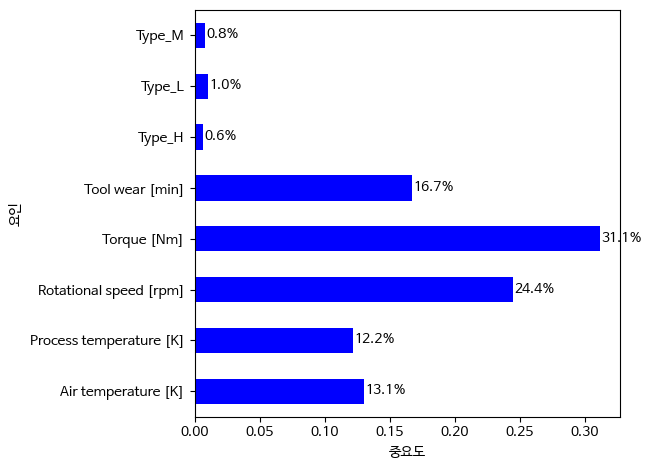

In [98]:
importance.plot(kind='barh',color='blue')
plt.xlabel('중요도')
plt.ylabel('요인')
plt.tight_layout()
for i,v in enumerate(importance.values):
  plt.text(v+0.001,i,f"{v:.1%}",color='black',va='center',ha='left')
plt.savefig('/content/drive/MyDrive/실습파일/importance',bbox_inches='tight')
plt.show()